# LoRA Fine-Tuning: Frozen vs Tuned Layer-Wise Probing for Speech Emotion Recognition

**Task 6: CSCI 535 Final Project**

Fine-tune each speech transformer end-to-end with a tiny LoRA adapter (rank 8) on each
emotion dataset, then re-run the same layer-wise LogisticRegression probe on the tuned
representations to measure which layers shift.

**Why LoRA?** Full fine-tuning on 24-layer 300M+ parameter transformers is expensive and
risks catastrophic forgetting. LoRA injects low-rank adapters into q_proj/v_proj of every
attention block, training only ~0.1% of parameters while still adapting the model to the
emotion task. After training, we extract hidden states from every layer again (including
the CNN feature encoder) and probe them with the same LogisticRegression pipeline Nima
used in EXP3, apples-to-apples delta vs the frozen baseline.

**Scope**: 6 models x 6 datasets = 36 fine-tune runs

Models: wav2vec2, HuBERT, Whisper, WavLM, MERT, w2v-BERT
Datasets: RAVDESS, EmoDB, IEMOCAP, SAVEE, AESDD, MESD

MSP-Podcast is excluded from LoRA because the raw audio is not shipped with the EXP3
release (it's a gated dataset). Its frozen probing baseline is still available in
Nima's `clean-summary/csv/{Model}_summary.csv` for reference in the layer_mixer notebook.


In [1]:
import numpy as np
import pandas as pd
import os, re, glob, json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoConfig, AutoFeatureExtractor
import transformers.modeling_utils
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from scipy.io import wavfile
from scipy.signal import resample
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Bypass CVE check (same as Nima's code)
if hasattr(transformers.modeling_utils, 'check_torch_load_is_safe'):
    transformers.modeling_utils.check_torch_load_is_safe = lambda: None

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Configuration & Paths

In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================
PROJECT_ROOT = '/Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final'
DATA_DIR = os.path.join(PROJECT_ROOT, 'my_code', 'data')

# Nima's new per-model clean baseline CSVs (one file per model, Dataset column inside)
NIMA_CLEAN_CSV_DIR = os.path.join(PROJECT_ROOT, 'TASK1-2-8', 'clean-summary', 'csv')

# Legacy CSV dir (old per-model-per-dataset format, 3 models only)
LEGACY_CSV_DIR = os.path.join(PROJECT_ROOT, 'EXP3 2', 'csv')

RESULTS_DIR = os.path.join(PROJECT_ROOT, 'my_code', 'results', 'lora')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# MODELS, HuggingFace checkpoints for every encoder in the 6-model family
# ============================================================
MODEL_CONFIGS = {
    'wav2vec2': 'facebook/wav2vec2-large-960h',
    'HuBERT':   'facebook/hubert-large-ll60k',
    'Whisper':  'openai/whisper-medium',
    'WavLM':    'microsoft/wavlm-large',
    'MERT':     'm-a-p/MERT-v1-330M',
    'w2v-BERT': 'facebook/w2v-bert-2.0',
}

# 7 datasets available locally (MSP-Podcast now unlocked from CARC project dir)
DATASETS = ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD', 'MSP-Podcast']

# Audio paths per dataset
AUDIO_PATHS = {
    'RAVDESS': os.path.join(DATA_DIR, 'RAVDESS'),
    'EmoDB':   os.path.join(DATA_DIR, 'EmoDB'),
    'IEMOCAP': os.path.join(DATA_DIR, 'IEMOCAP'),
    'SAVEE':   os.path.join(DATA_DIR, 'SAVEE'),
    'AESDD':   os.path.join(DATA_DIR, 'AESDD'),
    'MESD':    os.path.join(DATA_DIR, 'MESD'),
    'MSP-Podcast': os.path.join(DATA_DIR, 'MSP-Podcast'),
}

# ============================================================
# LoRA HYPERPARAMETERS
# ============================================================
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

# Training
BATCH_SIZE = 4
LR = 2e-4
EPOCHS = 5
SAMPLE_RATE = 16000
N_SPLITS = 3
RANDOM_STATE = 42

# Plot style (matching Nima's post_train.py)
PLOT_STYLE = {
    'frozen_color': '#2196F3',
    'tuned_color':  '#FF5722',
    'figsize':      (10, 5),
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_fontsize':  10,
    'legend_fontsize': 11,
    'grid_alpha':   0.3,
    'dpi':          300,
}
LAYER_LABELS = ['CNN'] + [str(i) for i in range(1, 25)]

print(f"Models ({len(MODEL_CONFIGS)}):")
for k, v in MODEL_CONFIGS.items():
    print(f"  {k:<10} -> {v}")
print(f"\nDatasets ({len(DATASETS)}): {DATASETS}")
print(f"\nLoRA: r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"Training: batch_size={BATCH_SIZE}, lr={LR}, epochs={EPOCHS}")
print(f"\nTotal LoRA experiments: {len(MODEL_CONFIGS) * len(DATASETS)}")


Models (6):
  wav2vec2   -> facebook/wav2vec2-large-960h
  HuBERT     -> facebook/hubert-large-ll60k
  Whisper    -> openai/whisper-medium
  WavLM      -> microsoft/wavlm-large
  MERT       -> m-a-p/MERT-v1-330M
  w2v-BERT   -> facebook/w2v-bert-2.0

Datasets (7): ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD', 'MSP-Podcast']

LoRA: r=8, alpha=16, dropout=0.1
Training: batch_size=4, lr=0.0002, epochs=5

Total LoRA experiments: 42


## 2. Audio Loading Functions

Adapted from `loader.py` in Nima's pipeline. Each function returns a list of `{file, label, audio}` dicts.

In [3]:
def load_audio_file(filepath, target_sr=16000):
    """Load and normalize a wav file (from Nima's loader.py)."""
    sr, waveform = wavfile.read(filepath)
    if waveform.dtype == np.int16:
        waveform = waveform.astype(np.float32) / 32768.0
    elif waveform.dtype == np.int32:
        waveform = waveform.astype(np.float32) / 2147483648.0
    else:
        waveform = waveform.astype(np.float32)
        if np.max(np.abs(waveform)) > 1.0:
            waveform = waveform / np.max(np.abs(waveform))
    if len(waveform.shape) > 1 and waveform.shape[1] > 1:
        waveform = np.mean(waveform, axis=1)
    if sr != target_sr:
        num_samples = int(len(waveform) * target_sr / sr)
        waveform = resample(waveform, num_samples)
    return waveform

def load_ravdess(path):
    EMAP = {'01':'neutral','02':'calm','03':'happy','04':'sad',
            '05':'angry','06':'fearful','07':'disgust','08':'surprised'}
    data = []
    for root, _, files in os.walk(path):
        for fn in files:
            if not fn.endswith('.wav'): continue
            parts = fn.replace('.wav','').split('-')
            if len(parts) < 3 or parts[2] not in EMAP: continue
            try:
                audio = load_audio_file(os.path.join(root, fn))
                data.append({'file': fn, 'label': EMAP[parts[2]], 'audio': audio})
            except: pass
    return data

def load_emodb(path):
    EMAP = {'W':'happy','L':'bored','E':'disgust','A':'fearful','F':'happy','T':'sad','N':'neutral'}
    data = []
    for root, _, files in os.walk(path):
        for fn in files:
            if not fn.endswith('.wav'): continue
            try:
                ec = fn[5]
                if ec not in EMAP: continue
                audio = load_audio_file(os.path.join(root, fn))
                data.append({'file': fn, 'label': EMAP[ec], 'audio': audio})
            except: pass
    return data

def load_iemocap(path):
    data = []
    meta_path = os.path.join(path, 'meta_data', 'meta_data.json')
    if not os.path.exists(meta_path):
        meta_path = os.path.join(path, 'meta_data.json')
    if not os.path.exists(meta_path):
        print("IEMOCAP meta_data.json not found.")
        return data
    with open(meta_path) as f:
        meta = json.load(f)
    # Build filename->path map
    path_map = {}
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith('.wav'):
                path_map[f] = os.path.join(root, f)
    for entry in tqdm(meta.get('meta_data', []), desc='IEMOCAP'):
        fname = os.path.basename(entry['path'])
        fpath = path_map.get(fname)
        if not fpath: continue
        try:
            audio = load_audio_file(fpath)
            data.append({'file': fname, 'label': entry['label'], 'audio': audio})
        except: pass
    return data

def load_savee(path):
    SMAP = {'a':'anger','d':'disgust','f':'fear','h':'happiness','n':'neutral','sa':'sadness','su':'surprise'}
    data = []
    for root, _, files in os.walk(path):
        for fn in files:
            if not fn.endswith('.wav'): continue
            m = re.match(r'^([A-Z]{2})_([a-z]+)(\d+)\.wav$', fn)
            if not m or m.group(2) not in SMAP: continue
            try:
                audio = load_audio_file(os.path.join(root, fn))
                data.append({'file': fn, 'label': SMAP[m.group(2)], 'audio': audio})
            except: pass
    return data

def load_aesdd(path):
    EMOTIONS = ['anger','disgust','fear','happiness','sadness']
    data = []
    for fpath in glob.glob(f'{path}/**/*.wav', recursive=True):
        parent = os.path.basename(os.path.dirname(fpath)).lower()
        emotion = next((e for e in EMOTIONS if e in parent), None)
        if not emotion: continue
        try:
            audio = load_audio_file(fpath)
            data.append({'file': os.path.basename(fpath), 'label': emotion, 'audio': audio})
        except: pass
    return data

def load_mesd(path):
    EMOTIONS = ['anger','disgust','fear','happiness','neutral','sadness']
    data = []
    for fpath in glob.glob(f'{path}/**/*.wav', recursive=True):
        parent = os.path.basename(os.path.dirname(fpath)).lower()
        fn_lower = os.path.basename(fpath).lower()
        emotion = next((e for e in EMOTIONS if e in parent or e in fn_lower), None)
        if not emotion: continue
        try:
            audio = load_audio_file(fpath)
            data.append({'file': os.path.basename(fpath), 'label': emotion, 'audio': audio})
        except: pass
    return data


def load_msp_podcast(path):
    """Load MSP-Podcast audio matching Nima's 4-class Test1 filter.

    Filter:
      - Split_Set == 'Test1' (16,903 candidate samples)
      - EmoClass in {N, H, A, S} -> 10,779 samples
    Classes mapped to: neutral, happiness, anger, sadness.
    This exactly matches the frozen .npy files from Nima (verified 10,779 samples).
    """
    csv_path = os.path.join(path, 'v1', 'labels_consensus.csv')
    audio_dir = os.path.join(path, 'v1', 'Audio')
    if not os.path.exists(csv_path):
        print(f"MSP-Podcast CSV not found at {csv_path}")
        return []
    df = pd.read_csv(csv_path)
    df = df[df['Split_Set'] == 'Test1']
    class_map = {'N': 'neutral', 'H': 'happiness', 'A': 'anger', 'S': 'sadness'}
    df = df[df['EmoClass'].isin(class_map.keys())].copy()
    df['emotion'] = df['EmoClass'].map(class_map)
    data = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='MSP-Podcast'):
        fpath = os.path.join(audio_dir, row['FileName'])
        if not os.path.exists(fpath):
            continue
        try:
            audio = load_audio_file(fpath)
            data.append({'file': row['FileName'], 'label': row['emotion'], 'audio': audio})
        except Exception:
            pass
    return data

LOADERS = {
    'RAVDESS': load_ravdess, 'EmoDB': load_emodb, 'IEMOCAP': load_iemocap,
    'SAVEE': load_savee, 'AESDD': load_aesdd, 'MESD': load_mesd,
    'MSP-Podcast': load_msp_podcast,
}
print("Audio loaders defined.")

Audio loaders defined.


## 3. SER LoRA Model & Audio Dataset

`SERLoRAModel` wraps a pretrained model with LoRA adapters on attention layers + a classification head.  
During forward pass, it returns logits AND all hidden states (for re-probing after training).

In [4]:
class AudioDataset(Dataset):
    """Simple dataset: pre-loaded audio arrays + integer labels."""
    def __init__(self, audios, labels):
        self.audios = audios
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.audios[idx], self.labels[idx]

def collate_fn_pad(batch):
    """Pad variable-length audio to the longest in the batch."""
    audios, labels = zip(*batch)
    max_len = max(a.shape[0] for a in audios)
    padded = torch.zeros(len(audios), max_len)
    for i, a in enumerate(audios):
        padded[i, :a.shape[0]] = a
    return padded, torch.tensor(labels, dtype=torch.long)


# MERT was pretrained at 24kHz, requires resampling from our 16kHz audio
MERT_SAMPLE_RATE = 24000


class SERLoRAModel(nn.Module):
    """Pretrained speech model + LoRA adapters + classification head."""
    
    def __init__(self, model_name, num_classes, lora_r=8, lora_alpha=16, lora_dropout=0.1):
        super().__init__()
        self.model_name = model_name
        self.is_whisper = 'whisper' in model_name.lower()
        self.is_mert = 'MERT' in model_name
        
        # Load pretrained model with hidden states output
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        config.output_hidden_states = True
        
        safe = 'MERT' not in model_name
        self.base_model = AutoModel.from_pretrained(
            model_name, config=config, use_safetensors=safe, trust_remote_code=True
        )
        
        # Feature extractor for preprocessing
        self.feature_extractor = AutoFeatureExtractor.from_pretrained(model_name, trust_remote_code=True)
        
        # Identify target modules for LoRA
        target_modules = self._find_attention_modules()
        if not target_modules:
            raise ValueError(f"Could not find attention modules in {model_name}. "
                             f"Available module names example: "
                             f"{[n for n, _ in list(self.base_model.named_modules())[:5]]}")
        
        # Apply LoRA
        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=target_modules,
            bias="none",
        )
        self.base_model = get_peft_model(self.base_model, lora_config)
        self.base_model.print_trainable_parameters()
        
        # Classification head
        hidden_size = config.hidden_size if hasattr(config, 'hidden_size') else config.d_model
        self.classifier = nn.Linear(hidden_size, num_classes)
    
    def _find_attention_modules(self):
        """Find attention projection module names. Tries 3 naming conventions:
        
        - wav2vec2 / HuBERT / Whisper / WavLM use q_proj / v_proj / k_proj
        - BERT-style models use query / key / value
        - w2v-BERT 2.0 (Conformer-based) uses linear_q / linear_k / linear_v
        """
        # Try 1: standard projection naming (matches end of module path exactly)
        target_names = []
        for name, _ in self.base_model.named_modules():
            leaf = name.split('.')[-1]
            if leaf in ['q_proj', 'v_proj', 'k_proj'] and leaf not in target_names:
                target_names.append(leaf)
        if target_names:
            print(f"  LoRA target modules (proj-style): {target_names}")
            return target_names
        
        # Try 2: BERT-style naming
        for name, _ in self.base_model.named_modules():
            leaf = name.split('.')[-1]
            if leaf in ['query', 'key', 'value'] and leaf not in target_names:
                target_names.append(leaf)
        if target_names:
            print(f"  LoRA target modules (bert-style): {target_names}")
            return target_names
        
        # Try 3: Conformer-style naming (w2v-BERT 2.0)
        for name, _ in self.base_model.named_modules():
            leaf = name.split('.')[-1]
            if leaf in ['linear_q', 'linear_k', 'linear_v'] and leaf not in target_names:
                target_names.append(leaf)
        if target_names:
            print(f"  LoRA target modules (conformer-style): {target_names}")
            return target_names
        
        print(f"  LoRA target modules: NONE FOUND -- inspect named_modules() manually")
        return target_names
    
    def forward(self, waveforms):
        """
        Args:
            waveforms: (batch, seq_len) raw audio tensor at 16kHz
        Returns:
            logits: (batch, num_classes)
            hidden_states: tuple of (batch, time, hidden_dim) per layer
        """
        # Preprocess
        waveform_list = [w.cpu().numpy() for w in waveforms]
        
        # MERT was pretrained at 24kHz; resample our 16kHz audio before its feature extractor
        if self.is_mert:
            from scipy.signal import resample as scipy_resample
            waveform_list = [scipy_resample(w, int(len(w) * MERT_SAMPLE_RATE / SAMPLE_RATE)) for w in waveform_list]
            target_sr = MERT_SAMPLE_RATE
        else:
            target_sr = SAMPLE_RATE
        
        # Whisper requires padding='max_length' so every clip is padded to 3000 mel frames (30s).
        # Default padding=True only pads to longest-in-batch which Whisper rejects.
        if self.is_whisper:
            inputs = self.feature_extractor(
                waveform_list, sampling_rate=target_sr,
                return_tensors="pt", padding="max_length"
            )
        else:
            inputs = self.feature_extractor(
                waveform_list, sampling_rate=target_sr,
                return_tensors="pt", padding=True
            )
        
        device = next(self.parameters()).device
        if self.is_whisper and "input_features" in inputs:
            model_inputs = {"input_features": inputs["input_features"].to(device)}
        elif "input_values" in inputs:
            model_inputs = {"input_values": inputs["input_values"].to(device)}
        else:
            model_inputs = {k: v.to(device) for k, v in inputs.items()}
        
        if self.is_whisper:
            outputs = self.base_model.encoder(**model_inputs)
        else:
            outputs = self.base_model(**model_inputs)
        
        hidden_states = outputs.hidden_states  # tuple of (batch, time, hidden_dim)
        
        # Mean pool the last hidden state for classification
        last_hidden = hidden_states[-1]
        pooled = last_hidden.mean(dim=1)  # (batch, hidden_dim)
        logits = self.classifier(pooled)
        
        return logits, hidden_states

print("SERLoRAModel and AudioDataset defined.")


SERLoRAModel and AudioDataset defined.


## 4. Fine-Tune & Extract Hidden States

For each model-dataset pair:
1. Fine-tune with LoRA + classification head (5-fold CV)
2. After training each fold, extract hidden states from ALL layers for the val set
3. Concatenate across folds to get tuned hidden states for re-probing

In [5]:
def finetune_and_extract(model_key, hf_name, dataset_name, audio_data, num_classes, le):
    """
    Fine-tune model with LoRA, then extract tuned hidden states for re-probing.
    
    Returns:
        dict with:
            - tuned_hidden_states: (num_samples, num_layers, hidden_dim)
            - labels: (num_samples,)
            - finetune_acc: classification accuracy from fine-tuning
            - finetune_f1: weighted F1 from fine-tuning
    """
    audios = [torch.FloatTensor(d['audio']) for d in audio_data]
    labels = le.transform([d['label'] for d in audio_data])
    
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    
    fold_accs, fold_f1s = [], []
    # Pre-allocate: will fill in per-fold val indices
    all_tuned_hs = [None] * len(labels)  # list indexed by sample
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(labels, labels)):
        print(f"  Fold {fold+1}/{N_SPLITS}...")
        
        train_ds = AudioDataset([audios[i] for i in train_idx], [labels[i] for i in train_idx])
        val_ds = AudioDataset([audios[i] for i in val_idx], [labels[i] for i in val_idx])
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_pad)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_pad)
        
        # Fresh model each fold
        model = SERLoRAModel(hf_name, num_classes, LORA_R, LORA_ALPHA, LORA_DROPOUT).to(DEVICE)
        
        # Only train LoRA params + classifier
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=LR)
        criterion = nn.CrossEntropyLoss()
        
        # Training loop
        for epoch in range(EPOCHS):
            model.train()
            epoch_loss = 0
            for batch_audio, batch_labels in train_loader:
                batch_labels = batch_labels.to(DEVICE)
                optimizer.zero_grad()
                logits, _ = model(batch_audio)
                loss = criterion(logits, batch_labels)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            if (epoch + 1) % 5 == 0:
                print(f"    Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")
        
        # Evaluate + extract hidden states from val set
        model.eval()
        val_preds, val_true = [], []
        val_hidden_states_per_layer = []  # list of lists
        
        with torch.no_grad():
            for batch_audio, batch_labels in val_loader:
                batch_labels_np = batch_labels.numpy()
                logits, hidden_states = model(batch_audio)
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(batch_labels_np)
                
                # Mean-pool each layer over time dim and collect
                batch_hs = []
                for layer_hs in hidden_states:
                    pooled = layer_hs.mean(dim=1).cpu().numpy()  # (batch, hidden_dim)
                    batch_hs.append(pooled)
                # batch_hs: list of num_layers arrays, each (batch, hidden_dim)
                # Transpose to per-sample
                batch_size_actual = len(batch_labels_np)
                for i in range(batch_size_actual):
                    sample_hs = np.stack([batch_hs[l][i] for l in range(len(batch_hs))])
                    # sample_hs: (num_layers, hidden_dim)
                    val_hidden_states_per_layer.append(sample_hs)
        
        fold_acc = accuracy_score(val_true, val_preds)
        fold_f1 = f1_score(val_true, val_preds, average='weighted')
        fold_accs.append(fold_acc)
        fold_f1s.append(fold_f1)
        print(f"    Fold {fold+1}, Acc: {fold_acc:.4f}, F1: {fold_f1:.4f}")
        
        # Store tuned hidden states at original indices
        for i, orig_idx in enumerate(val_idx):
            all_tuned_hs[orig_idx] = val_hidden_states_per_layer[i]
        
        # Cleanup
        del model, optimizer, trainable_params
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    
    # Stack all samples: (num_samples, num_layers, hidden_dim)
    tuned_hs = np.stack(all_tuned_hs)
    
    result = {
        'tuned_hidden_states': tuned_hs,
        'labels': labels,
        'finetune_acc': np.mean(fold_accs),
        'finetune_std': np.std(fold_accs),
        'finetune_f1': np.mean(fold_f1s),
    }
    
    print(f"  {model_key}/{dataset_name}, FT Acc: {result['finetune_acc']:.4f}±{result['finetune_std']:.4f} | "
          f"Tuned HS shape: {tuned_hs.shape}")
    
    return result

print("finetune_and_extract() defined.")

finetune_and_extract() defined.


## 5. Layer-Wise Probing (Matching Frozen Pipeline)

Same `LogisticRegression(max_iter=1000, solver='lbfgs')` + `StandardScaler` + 5-fold CV as Nima's `train.py`.

In [6]:
def probe_all_layers(hidden_states, labels):
    """
    Run LogisticRegression probing on each layer's representations.
    Matches train.py methodology exactly.
    
    Args:
        hidden_states: (num_samples, num_layers, hidden_dim)
        labels: (num_samples,) integer labels
    
    Returns:
        DataFrame with Layer, Layer_Num, Accuracy, Std_Accuracy, Weighted_F1
    """
    num_layers = hidden_states.shape[1]
    results = []
    
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    
    for layer_idx in range(num_layers):
        X = hidden_states[:, layer_idx, :]  # (num_samples, hidden_dim)
        
        fold_accs, fold_f1s = [], []
        for train_idx, val_idx in skf.split(X, labels):
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X[train_idx])
            X_val = scaler.transform(X[val_idx])
            
            clf = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
            clf.fit(X_train, labels[train_idx])
            preds = clf.predict(X_val)
            
            fold_accs.append(accuracy_score(labels[val_idx], preds))
            fold_f1s.append(f1_score(labels[val_idx], preds, average='weighted'))
        
        layer_name = 'CNN' if layer_idx == 0 else str(layer_idx)
        results.append({
            'Layer': layer_name,
            'Layer_Num': layer_idx,
            'Accuracy': np.mean(fold_accs),
            'Std_Accuracy': np.std(fold_accs),
            'Weighted_F1': np.mean(fold_f1s),
        })
    
    return pd.DataFrame(results)

print("probe_all_layers() defined.")

probe_all_layers() defined.


## 6. Load All Audio Datasets

Load raw audio for all 6 datasets. This takes a few minutes for IEMOCAP (5531 files).

In [7]:
audio_data = {}
label_encoders = {}

# Only load the datasets we'll actually fine-tune (matches DATASET_ORDER in cell 15)
LOAD_DATASETS = ['EmoDB', 'SAVEE', 'AESDD', 'MESD', 'RAVDESS']
for dataset in LOAD_DATASETS:
    path = AUDIO_PATHS[dataset]
    loader_fn = LOADERS[dataset]
    
    print(f"\nLoading {dataset} from {path}...")
    data = loader_fn(path)
    
    if not data:
        print(f"  WARNING: No audio loaded for {dataset}!")
        continue
    
    # Encode labels
    le = LabelEncoder()
    all_labels = [d['label'] for d in data]
    le.fit(all_labels)
    
    audio_data[dataset] = data
    label_encoders[dataset] = le
    
    print(f"  {dataset}: {len(data)} samples, {len(le.classes_)} classes: {list(le.classes_)}")

print(f"\nLoaded {len(audio_data)}/{len(LOAD_DATASETS)} datasets.")


Loading EmoDB from /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/data/EmoDB...


  EmoDB: 535 samples, 6 classes: [np.str_('bored'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]

Loading SAVEE from /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/data/SAVEE...


  SAVEE: 480 samples, 7 classes: [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness'), np.str_('surprise')]

Loading AESDD from /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/data/AESDD...


  AESDD: 604 samples, 5 classes: [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('sadness')]

Loading MESD from /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/data/MESD...


  MESD: 862 samples, 6 classes: [np.str_('anger'), np.str_('disgust'), np.str_('fear'), np.str_('happiness'), np.str_('neutral'), np.str_('sadness')]

Loading RAVDESS from /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/data/RAVDESS...


  RAVDESS: 2880 samples, 8 classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]

Loaded 5/5 datasets.


## 7. Run LoRA Fine-Tuning + Hidden State Extraction

Main compute cell. For each model-dataset combo:
1. Fine-tune with LoRA (5-fold CV, 10 epochs)
2. Extract tuned hidden states from all layers
3. Save tuned hidden states as .npy

**WARNING**: This is compute-heavy. IEMOCAP takes several hours on MPS. Start with EmoDB (smallest) as a smoke test.

In [8]:
import gc
import traceback
from datetime import datetime

# Order: smallest -> largest for smoke testing (IEMOCAP last because it takes ~2-4 hr on MPS)
DATASET_ORDER = ['EmoDB', 'SAVEE', 'AESDD', 'MESD', 'RAVDESS']  # trimmed: big datasets (IEMOCAP, MSP-Podcast) excluded for runtime

lora_results = {}
failed_runs = []

# Persistent log so any helper (Claude, future me) can read failures from disk
LOG_PATH = os.path.join(RESULTS_DIR, 'lora_run_log.txt')
log_lines = [f"=== LoRA run started at {datetime.now().isoformat()} ===", ""]

def _flush_log():
    with open(LOG_PATH, 'w') as f:
        f.write('\n'.join(log_lines))

for model_key, hf_name in MODEL_CONFIGS.items():
    for dataset in DATASET_ORDER:
        if dataset not in audio_data:
            print(f"SKIP {model_key}/{dataset} -- no audio loaded")
            log_lines.append(f"SKIP {model_key}/{dataset} -- no audio loaded")
            continue

        key = (model_key, dataset)
        save_path = os.path.join(RESULTS_DIR, f'tuned_hidden_states_{model_key}_{dataset}.npy')
        labels_path = os.path.join(RESULTS_DIR, f'tuned_labels_{model_key}_{dataset}.npy')

        # Skip if already computed -- load cached tuned hidden states
        if os.path.exists(save_path) and os.path.exists(labels_path):
            print(f"CACHED {model_key}/{dataset} -- loading from disk")
            tuned_hs = np.load(save_path)
            labels = np.load(labels_path)
            lora_results[key] = {
                'tuned_hidden_states': tuned_hs,
                'labels': labels,
                'finetune_acc': None,
                'finetune_std': None,
                'finetune_f1':  None,
            }
            log_lines.append(f"CACHED {model_key}/{dataset}")
            continue

        print(f"\n{'='*60}")
        print(f"Fine-tuning {model_key} on {dataset} ({len(audio_data[dataset])} samples)")
        print(f"{'='*60}")
        log_lines.append(f"\n{'='*60}")
        log_lines.append(f"START {model_key}/{dataset}  ({len(audio_data[dataset])} samples)  at {datetime.now().isoformat()}")

        le = label_encoders[dataset]
        num_classes = len(le.classes_)

        try:
            result = finetune_and_extract(
                model_key, hf_name, dataset,
                audio_data[dataset], num_classes, le,
            )
            lora_results[key] = result
            np.save(save_path, result['tuned_hidden_states'])
            np.save(labels_path, result['labels'])
            print(f"  Saved: {save_path}")
            log_lines.append(f"DONE {model_key}/{dataset}: acc={result['finetune_acc']:.4f}±{result['finetune_std']:.4f}")
        except Exception as e:
            tb = traceback.format_exc()
            print(f"\n  !!! FAILED {model_key}/{dataset}: {type(e).__name__}: {e}")
            print(tb)
            failed_runs.append((model_key, dataset, str(e)))
            log_lines.append(f"FAILED {model_key}/{dataset}: {type(e).__name__}: {e}")
            log_lines.append(tb)

        # Hard cleanup between combos so the next one starts fresh
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        elif torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Flush log after every combo so a kernel crash mid-run still leaves a trace
        _flush_log()

log_lines.append(f"\n=== Run finished at {datetime.now().isoformat()} ===")
log_lines.append(f"Completed: {len(lora_results)} combos")
log_lines.append(f"Failed: {len(failed_runs)}")
_flush_log()

print(f"\nCompleted {len(lora_results)} LoRA experiments.")
print(f"Log written to: {LOG_PATH}")
if failed_runs:
    print(f"Failed: {len(failed_runs)}")
    for model_key, dataset, err in failed_runs:
        print(f"  {model_key}/{dataset}: {err[:120]}")


CACHED wav2vec2/EmoDB, loading from disk
CACHED wav2vec2/SAVEE, loading from disk
CACHED wav2vec2/AESDD, loading from disk
CACHED wav2vec2/MESD, loading from disk
CACHED wav2vec2/RAVDESS, loading from disk
CACHED HuBERT/EmoDB, loading from disk
CACHED HuBERT/SAVEE, loading from disk
CACHED HuBERT/AESDD, loading from disk
CACHED HuBERT/MESD, loading from disk
CACHED HuBERT/RAVDESS, loading from disk
CACHED Whisper/EmoDB, loading from disk
CACHED Whisper/SAVEE, loading from disk
CACHED Whisper/AESDD, loading from disk


CACHED Whisper/MESD, loading from disk
CACHED Whisper/RAVDESS, loading from disk
CACHED WavLM/EmoDB, loading from disk
CACHED WavLM/SAVEE, loading from disk
CACHED WavLM/AESDD, loading from disk
CACHED WavLM/MESD, loading from disk
CACHED WavLM/RAVDESS, loading from disk
CACHED MERT/EmoDB, loading from disk
CACHED MERT/SAVEE, loading from disk
CACHED MERT/AESDD, loading from disk
CACHED MERT/MESD, loading from disk
CACHED MERT/RAVDESS, loading from disk


CACHED w2v-BERT/EmoDB, loading from disk
CACHED w2v-BERT/SAVEE, loading from disk
CACHED w2v-BERT/AESDD, loading from disk
CACHED w2v-BERT/MESD, loading from disk
CACHED w2v-BERT/RAVDESS, loading from disk

Completed 30 LoRA experiments.
Log written to: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/lora/lora_run_log.txt


## 8. Re-Probe Tuned Hidden States + Load Frozen Baselines

Run the same LogisticRegression probing on tuned hidden states, and load the frozen probing CSVs for comparison.

In [9]:
tuned_probing = {}
frozen_probing = {}

# 1. Re-probe every tuned hidden-state tensor with the exact same LogisticRegression pipeline
for key, result in lora_results.items():
    model_key, dataset = key
    print(f"Probing tuned states: {model_key}/{dataset}...")

    hs = result['tuned_hidden_states']
    labels = result['labels']

    tuned_df = probe_all_layers(hs, labels)
    tuned_probing[key] = tuned_df

    csv_path = os.path.join(RESULTS_DIR, f'tuned_probing_{model_key}_{dataset}.csv')
    tuned_df.to_csv(csv_path, index=False)

    best_idx = tuned_df['Accuracy'].idxmax()
    print(f"  Best tuned layer: {tuned_df.loc[best_idx, 'Layer']} "
          f"(Acc={tuned_df.loc[best_idx, 'Accuracy']:.4f})")

# 2. Load frozen probing baselines from Nima's NEW per-model CSV format
#    ({NIMA_CLEAN_CSV_DIR}/{Model}_summary.csv; Dataset column inside).
#    Falls back to the legacy per-model-per-dataset format if the new file is absent.
for model_key in MODEL_CONFIGS:
    per_model_csv = os.path.join(NIMA_CLEAN_CSV_DIR, f'{model_key}_summary.csv')
    if os.path.exists(per_model_csv):
        df_full = pd.read_csv(per_model_csv)
        for dataset in DATASETS:
            df = df_full[df_full['Dataset'] == dataset].sort_values('Layer_Num').reset_index(drop=True)
            if len(df) > 0:
                frozen_probing[(model_key, dataset)] = df
            else:
                print(f"  No rows for {model_key}/{dataset} in {os.path.basename(per_model_csv)}")
    else:
        # Legacy fallback
        for dataset in DATASETS:
            legacy_csv = os.path.join(LEGACY_CSV_DIR, f'results_{model_key}_{dataset}.csv')
            if os.path.exists(legacy_csv):
                frozen_probing[(model_key, dataset)] = pd.read_csv(legacy_csv)
            else:
                print(f"Missing frozen baseline for {model_key}/{dataset}")

print(f"\nTuned probing: {len(tuned_probing)} experiments")
print(f"Frozen probing: {len(frozen_probing)} baselines loaded")


Probing tuned states: wav2vec2/EmoDB...


  Best tuned layer: 7 (Acc=0.9720)
Probing tuned states: wav2vec2/SAVEE...


  Best tuned layer: 11 (Acc=0.8083)
Probing tuned states: wav2vec2/AESDD...


  Best tuned layer: 6 (Acc=0.8940)
Probing tuned states: wav2vec2/MESD...


  Best tuned layer: 3 (Acc=0.7842)
Probing tuned states: wav2vec2/RAVDESS...


...

  Best tuned layer: 4 (Acc=0.9083)
Probing tuned states: w2v-BERT/SAVEE...


  Best tuned layer: 17 (Acc=0.7854)
Probing tuned states: w2v-BERT/AESDD...


  Best tuned layer: 17 (Acc=0.8659)
Probing tuned states: w2v-BERT/MESD...


  Best tuned layer: 17 (Acc=0.8190)
Probing tuned states: w2v-BERT/RAVDESS...


  Best tuned layer: 1 (Acc=0.8667)

Tuned probing: 30 experiments
Frozen probing: 42 baselines loaded


## 9. Frozen vs Tuned Probing Comparison Plots

Two-panel plots per model-dataset: frozen curve (dashed blue) + tuned curve (solid orange). Highlights where LoRA changes the probing profile.

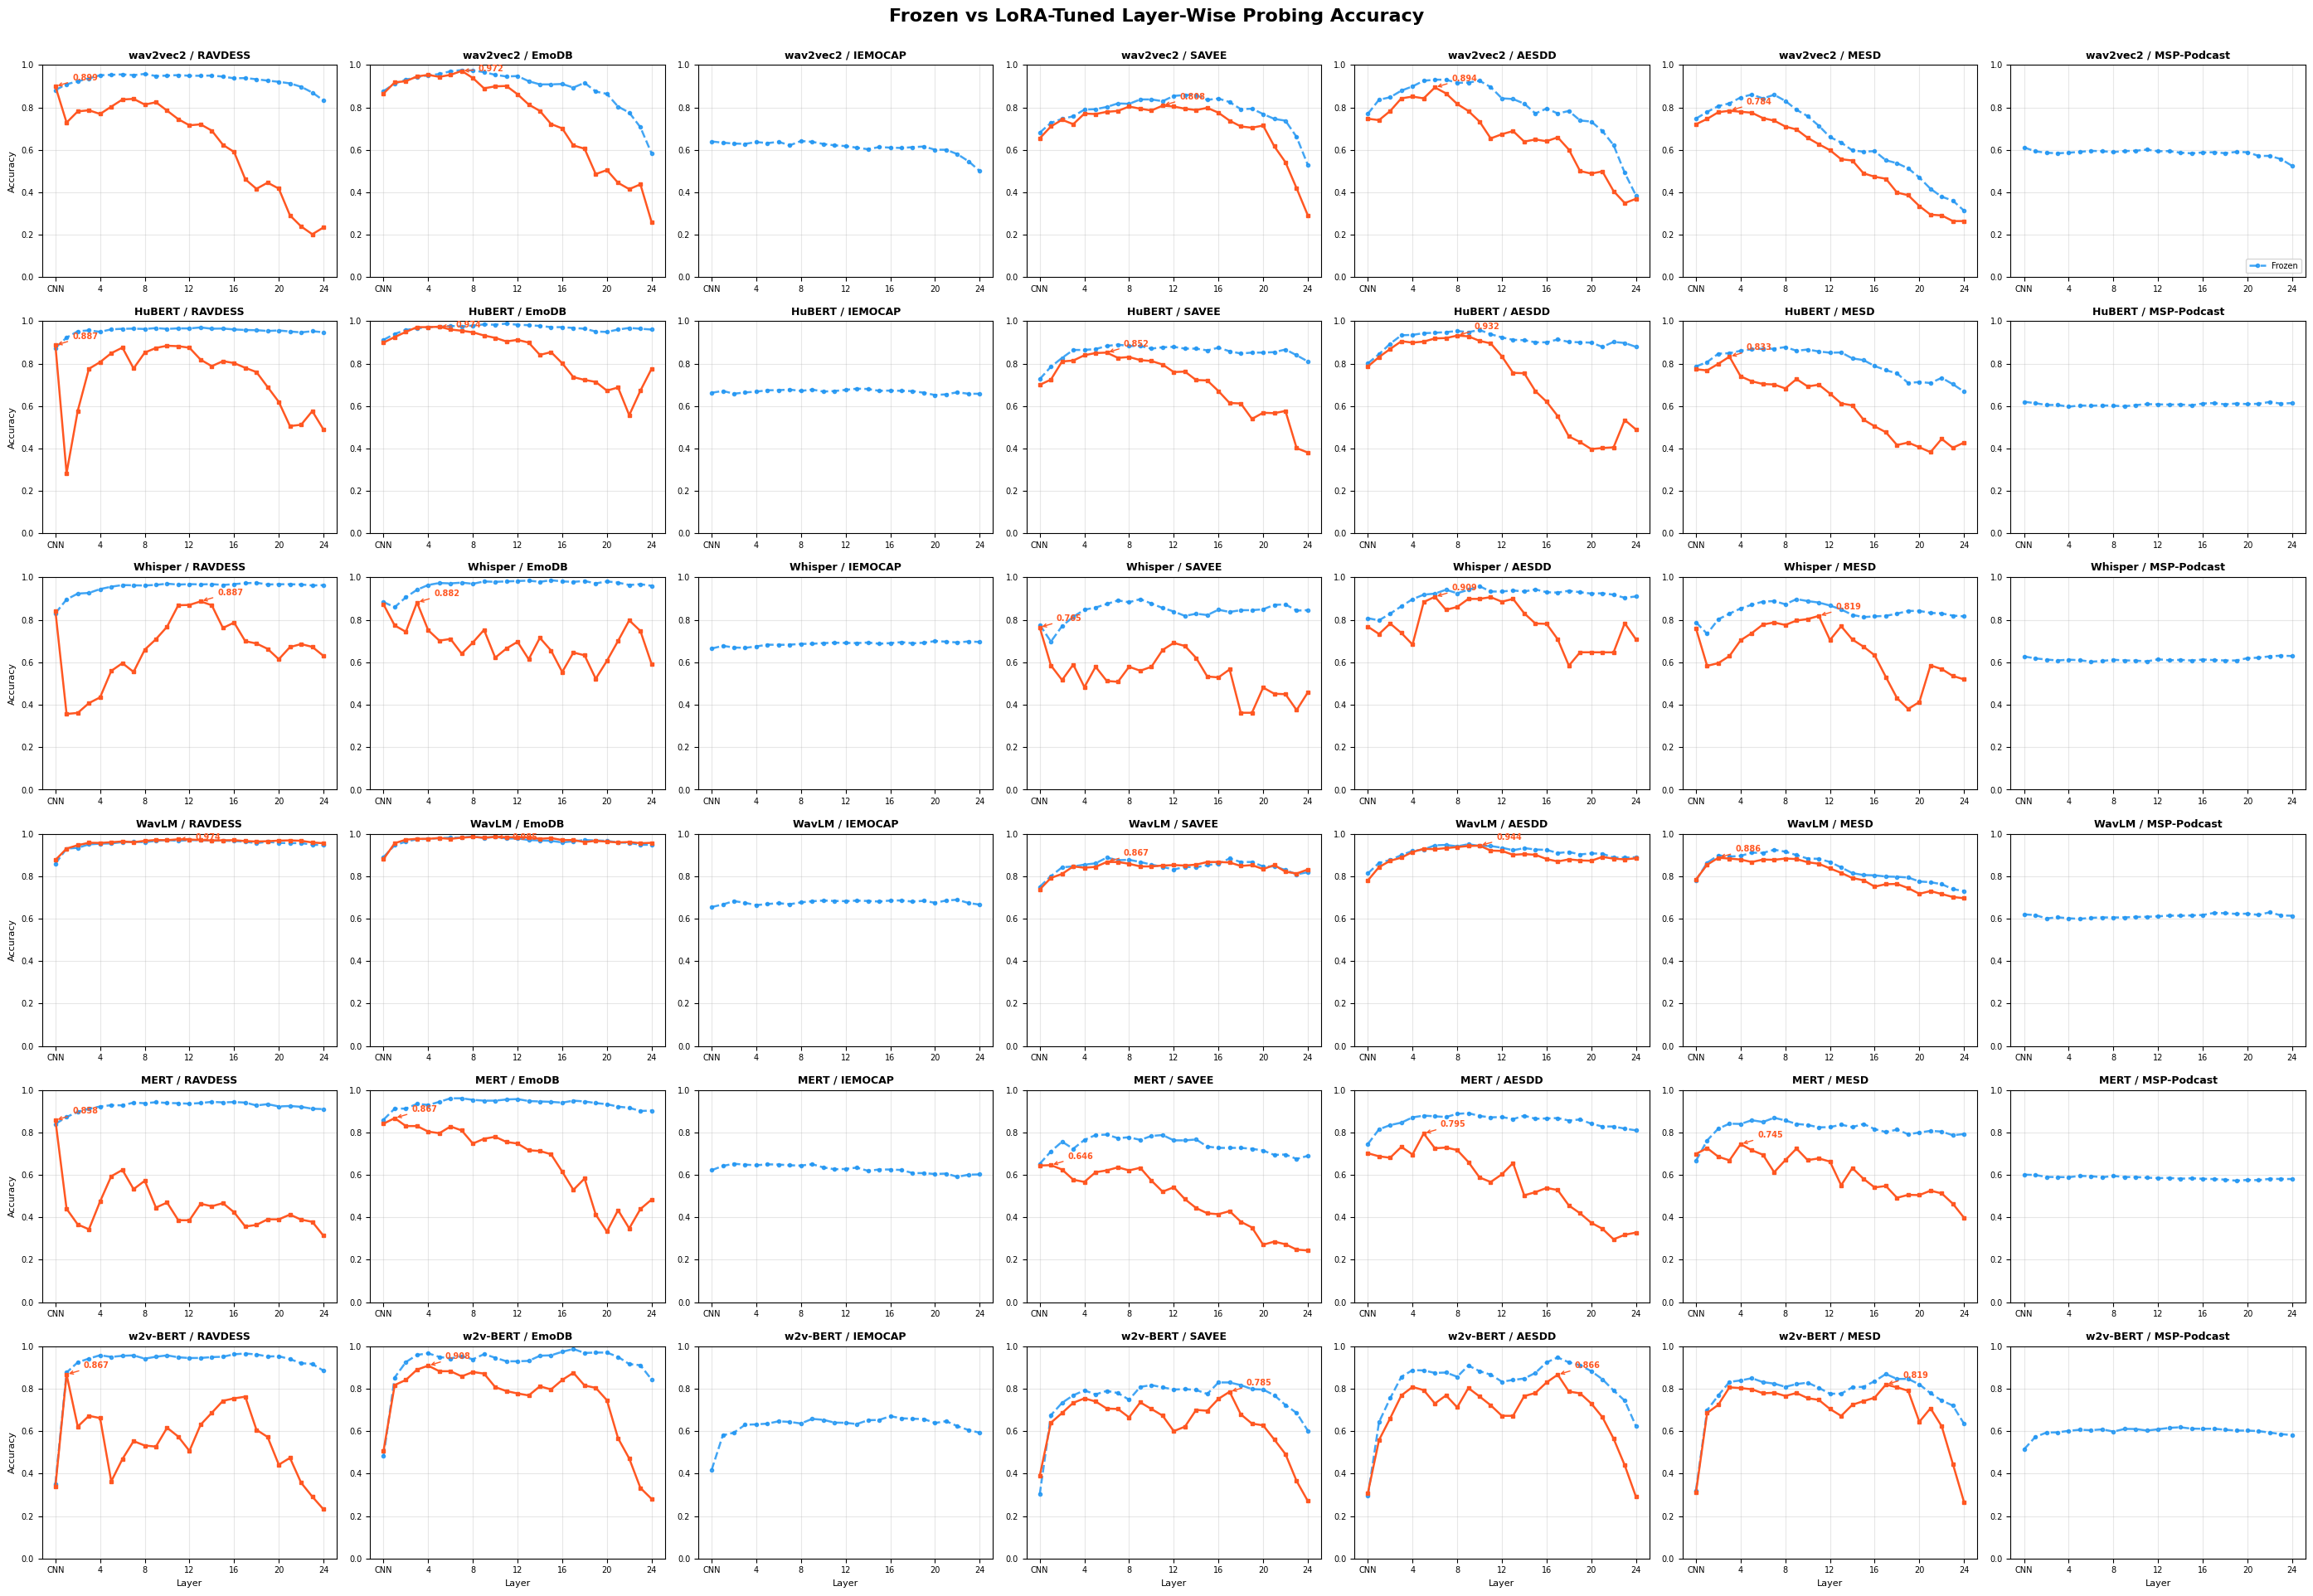

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/lora/frozen_vs_tuned_probing.png


In [10]:
n_models = len(MODEL_CONFIGS)
n_datasets = len(DATASETS)
fig, axes = plt.subplots(n_models, n_datasets,
                          figsize=(4.0 * n_datasets, 3.2 * n_models), squeeze=False)

for m_idx, model_key in enumerate(MODEL_CONFIGS):
    for d_idx, dataset in enumerate(DATASETS):
        ax = axes[m_idx][d_idx]
        key = (model_key, dataset)

        # Frozen probing curve
        if key in frozen_probing:
            df_f = frozen_probing[key]
            ax.plot(df_f['Layer_Num'], df_f['Accuracy'],
                    color=PLOT_STYLE['frozen_color'], marker='o', linewidth=1.8,
                    linestyle='--', label='Frozen', markersize=3, alpha=0.85)

        # Tuned probing curve
        if key in tuned_probing:
            df_t = tuned_probing[key]
            ax.plot(df_t['Layer_Num'], df_t['Accuracy'],
                    color=PLOT_STYLE['tuned_color'], marker='s', linewidth=1.8,
                    linestyle='-', label='LoRA-Tuned', markersize=3)

            best_idx = df_t['Accuracy'].idxmax()
            best_acc = df_t.loc[best_idx, 'Accuracy']
            best_layer = df_t.loc[best_idx, 'Layer_Num']
            ax.annotate(f'{best_acc:.3f}', xy=(best_layer, best_acc),
                        xytext=(best_layer + 1.5, min(best_acc + 0.03, 0.97)),
                        fontsize=7, fontweight='bold', color=PLOT_STYLE['tuned_color'],
                        arrowprops=dict(arrowstyle='->', color=PLOT_STYLE['tuned_color']))

        ax.set_title(f'{model_key} / {dataset}', fontsize=9, fontweight='bold')
        ax.set_ylim([0, 1.0])
        ax.set_xticks(range(0, 25, 4))
        ax.set_xticklabels([LAYER_LABELS[i] for i in range(0, 25, 4)], fontsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])
        if m_idx == 0 and d_idx == n_datasets - 1:
            ax.legend(fontsize=7, loc='lower right')

        if m_idx == n_models - 1:
            ax.set_xlabel('Layer', fontsize=8)
        if d_idx == 0:
            ax.set_ylabel('Accuracy', fontsize=8)

plt.suptitle('Frozen vs LoRA-Tuned Layer-Wise Probing Accuracy',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'frozen_vs_tuned_probing.png')
plt.savefig(plot_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {plot_path}")


## 10. Per-Layer Delta Analysis

Compute accuracy delta (tuned - frozen) at every layer. Positive = LoRA helped that layer; negative = hurt.  
Key question: Do deep layers recover after fine-tuning (especially for wav2vec2)?

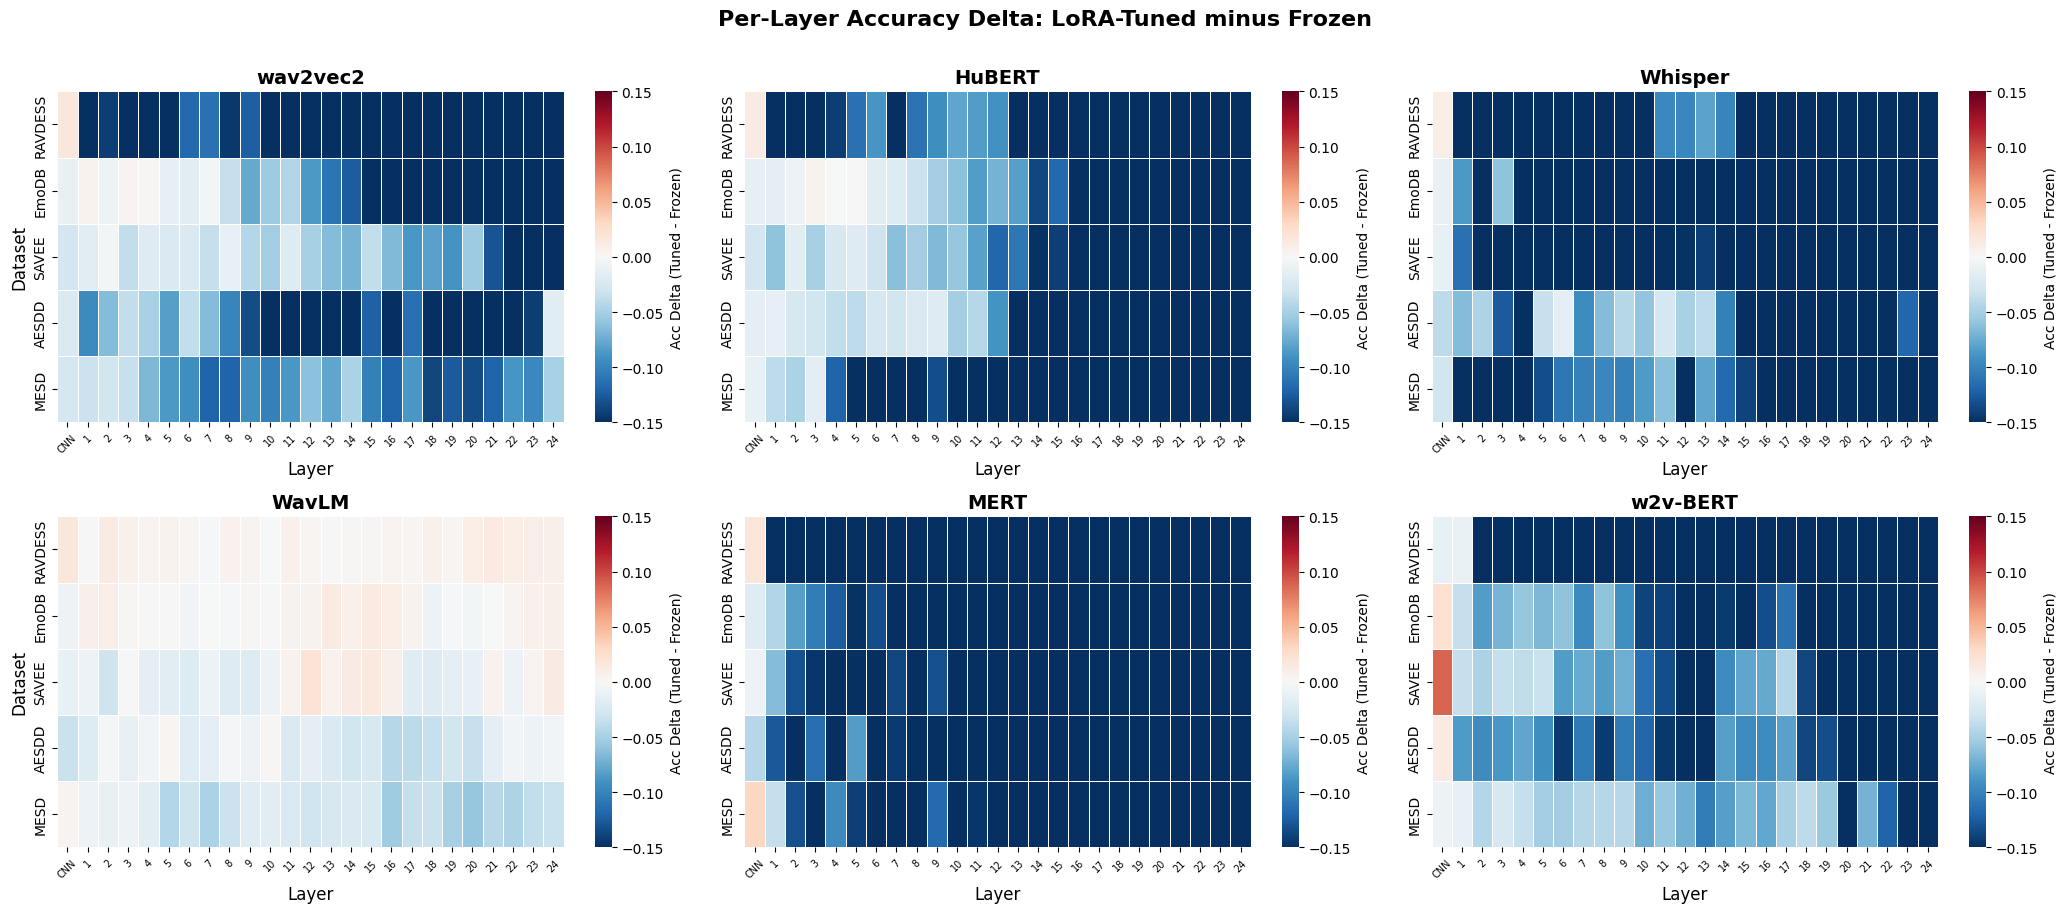

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/lora/per_layer_delta_heatmap.png
Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/lora/frozen_vs_tuned_comparison.csv

   Model Dataset Frozen_Best_Layer  Frozen_Best_Acc Tuned_Best_Layer  Tuned_Best_Acc  Best_Acc_Delta  Mean_Delta_All  Mean_Delta_Deep(18-24)
wav2vec2 RAVDESS           Layer 8           0.9577              CNN        0.898958       -0.058742       -0.302871               -0.578010
wav2vec2   EmoDB           Layer 7           0.9757                7        0.972004       -0.003696       -0.144453               -0.338579
wav2vec2   SAVEE          Layer 13           0.8583               11        0.808333       -0.049967       -0.068841               -0.147040
wav2vec2   AESDD           Layer 6           0.9305                6        0.894036       -0.036464       -0.129577               -0.175920
wav2vec2    MESD           Layer 5           0.8608                3       

In [11]:
import seaborn as sns

# Per-layer delta heatmap, 6 models in 2x3 grid
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

comparison_rows = []

for m_idx, model_key in enumerate(MODEL_CONFIGS):
    ax = axes[m_idx]
    delta_matrix = []
    ds_labels = []

    for dataset in DATASETS:
        key = (model_key, dataset)
        if key in tuned_probing and key in frozen_probing:
            df_t = tuned_probing[key]
            df_f = frozen_probing[key]

            n_layers = min(len(df_t), len(df_f))
            delta = df_t['Accuracy'].values[:n_layers] - df_f['Accuracy'].values[:n_layers]
            delta_matrix.append(delta)
            ds_labels.append(dataset)

            frozen_best_idx = df_f['Accuracy'].idxmax()
            tuned_best_idx  = df_t['Accuracy'].idxmax()
            comparison_rows.append({
                'Model': model_key,
                'Dataset': dataset,
                'Frozen_Best_Layer': df_f.loc[frozen_best_idx, 'Layer'],
                'Frozen_Best_Acc':   float(df_f.loc[frozen_best_idx, 'Accuracy']),
                'Tuned_Best_Layer':  df_t.loc[tuned_best_idx, 'Layer'],
                'Tuned_Best_Acc':    float(df_t.loc[tuned_best_idx, 'Accuracy']),
                'Best_Acc_Delta':    float(df_t.loc[tuned_best_idx, 'Accuracy']
                                           - df_f.loc[frozen_best_idx, 'Accuracy']),
                'Mean_Delta_All':    float(delta.mean()),
                'Mean_Delta_Deep(18-24)': float(delta[18:].mean()) if len(delta) > 18 else np.nan,
            })

    if delta_matrix:
        delta_matrix = np.array(delta_matrix)
        sns.heatmap(delta_matrix, ax=ax,
                    xticklabels=LAYER_LABELS[:delta_matrix.shape[1]],
                    yticklabels=ds_labels,
                    cmap='RdBu_r', center=0,
                    cbar_kws={'label': 'Acc Delta (Tuned - Frozen)'},
                    linewidths=0.5, vmin=-0.15, vmax=0.15)
        ax.set_title(f'{model_key}', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
        ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
        if m_idx % n_cols == 0:
            ax.set_ylabel('Dataset', fontsize=PLOT_STYLE['label_fontsize'])
        ax.tick_params(axis='x', labelsize=7, rotation=45)
    else:
        ax.set_title(f'{model_key} (no data)', fontsize=10)
        ax.axis('off')

# Hide any extra subplots
for i in range(n_models, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Per-Layer Accuracy Delta: LoRA-Tuned minus Frozen',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

delta_path = os.path.join(RESULTS_DIR, 'per_layer_delta_heatmap.png')
plt.savefig(delta_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {delta_path}")

# Comparison table
comparison_df = pd.DataFrame(comparison_rows)
comp_path = os.path.join(RESULTS_DIR, 'frozen_vs_tuned_comparison.csv')
comparison_df.to_csv(comp_path, index=False)
print(f"Saved: {comp_path}\n")
print(comparison_df.to_string(index=False))


## 11. Save All Results

Export summary CSV and list all output files.

In [12]:
# Summary table
summary_rows = []
for key, result in lora_results.items():
    model_key, dataset = key
    tuned_df = tuned_probing.get(key)
    frozen_df = frozen_probing.get(key)
    
    if tuned_df is not None:
        t_best = tuned_df.loc[tuned_df['Accuracy'].idxmax()]
    else:
        continue
    
    row = {
        'Model': model_key,
        'Dataset': dataset,
        'Tuned_Best_Layer': t_best['Layer'],
        'Tuned_Best_Acc': t_best['Accuracy'],
        'Tuned_Best_F1': t_best['Weighted_F1'],
    }
    
    if frozen_df is not None:
        f_best = frozen_df.loc[frozen_df['Accuracy'].idxmax()]
        row['Frozen_Best_Layer'] = f_best['Layer']
        row['Frozen_Best_Acc'] = f_best['Accuracy']
        row['Delta_Best_Acc'] = t_best['Accuracy'] - f_best['Accuracy']
    
    if result.get('finetune_acc') is not None:
        row['FT_Classification_Acc'] = result['finetune_acc']
    
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, 'lora_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}\n")

# List all outputs
print(f"{'='*60}")
print(f"All outputs in: {RESULTS_DIR}")
print(f"{'='*60}")
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, f)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  {f:<50} {size_mb:>8.1f} MB")

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/lora/lora_summary.csv

All outputs in: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/lora
  frozen_vs_tuned_comparison.csv                          0.0 MB
  frozen_vs_tuned_probing.png                             1.7 MB
  lora_run_log.txt                                        0.0 MB
  lora_summary.csv                                        0.0 MB
  per_layer_delta_heatmap.png                             0.3 MB
  tuned_hidden_states_HuBERT_AESDD.npy                   59.0 MB
  tuned_hidden_states_HuBERT_EmoDB.npy                   52.2 MB
  tuned_hidden_states_HuBERT_MESD.npy                    84.2 MB
  tuned_hidden_states_HuBERT_RAVDESS.npy                281.3 MB
  tuned_hidden_states_HuBERT_SAVEE.npy                   46.9 MB
  tuned_hidden_states_MERT_AESDD.npy                     59.0 MB
  tuned_hidden_states_MERT_EmoDB.npy                     52.2 MB
  tuned_hidden_states_MERT_MESD.n